# Importing the libraries


In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Import essential libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style for Colab
%matplotlib inline
sns.set_style("whitegrid")

Mounted at /content/drive


# Pulling the data and starting to EDA

In [ ]:
# Define the file path (Update this if your folder name/path is different)
file_path = '/content/drive/MyDrive/BIL476/creditcard.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# 1. Display the shape of the dataset (checking minimum requirements)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# 2. Preview the first 5 rows of the dataset
print("First 5 rows of the dataset:")
display(df.head())

# 3. Check for any missing (null) values in the dataset
print("\nMaximum number of missing values in any column:")
print(df.isnull().sum().max()) # Expected output is 0

# 4. Analyze the class distribution to highlight the extreme imbalance
print("\nClass Distribution (0: Normal, 1: Fraudulent):")
print(df['Class'].value_counts())

# Calculate and display the percentage of fraudulent transactions
fraud_percentage = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"\nPercentage of Fraudulent Transactions: {round(fraud_percentage, 3)}%")

Dataset Shape: 284807 rows, 31 columns

First 5 rows of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Maximum number of missing values in any column:
0

Class Distribution (0: Normal, 1: Fraudulent):
Class
0    284315
1       492
Name: count, dtype: int64

Percentage of Fraudulent Transactions: 0.173%


# Visualization

/tmp/ipykernel_323/1120703132.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2')


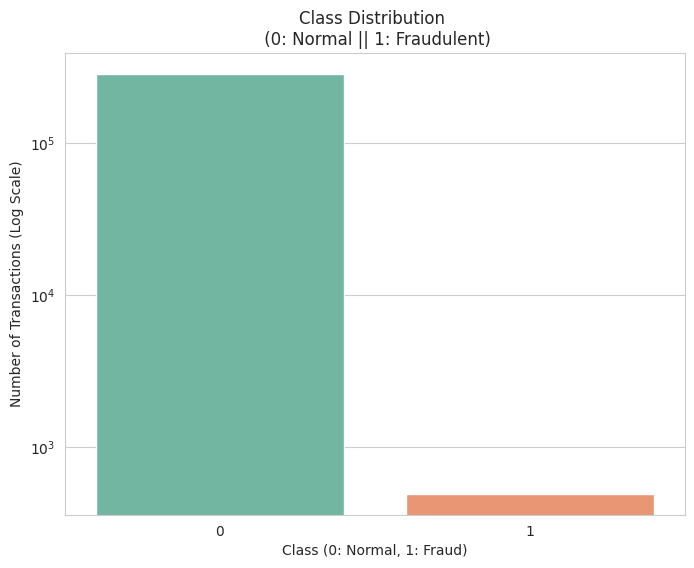

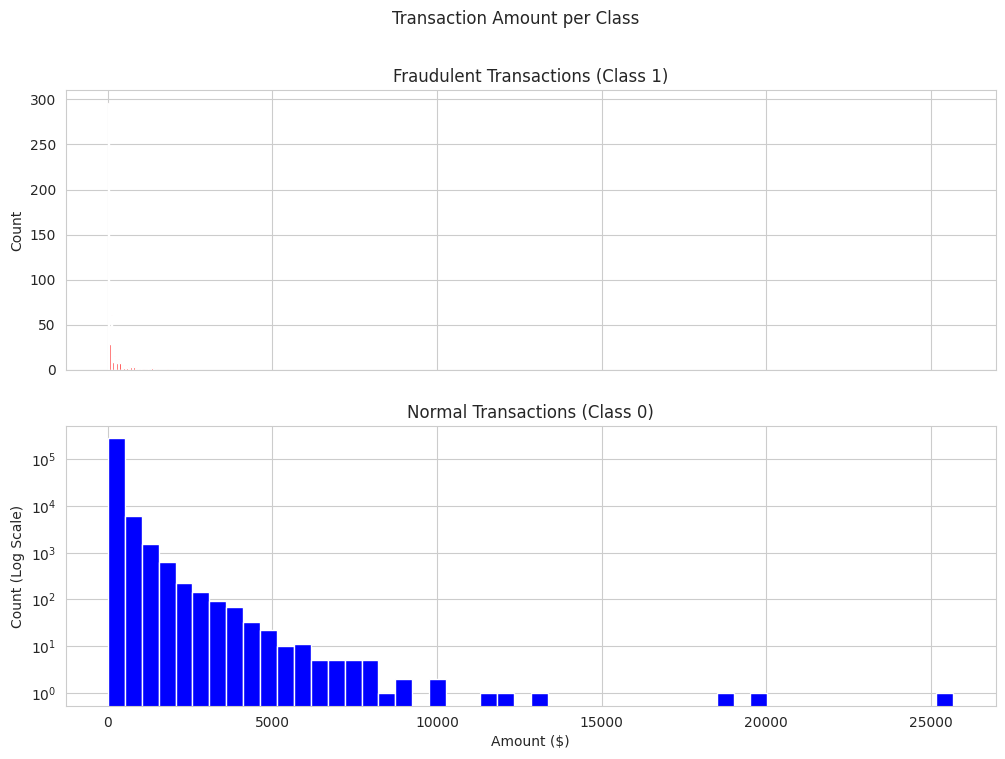

In [ ]:
# Create a figure for class distribution
plt.figure(figsize=(8, 6))

# Plot the count of each class
# Using logarithmic scale on y-axis because of the extreme imbalance
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Class Distribution \n (0: Normal || 1: Fraudulent)')
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Number of Transactions (Log Scale)')
plt.yscale('log')
plt.show()

print("\n" + "="*50 + "\n")

# Create subplots to compare transaction amounts for both classes
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))
fig.suptitle('Transaction Amount per Class')

# Plot histogram for fraudulent transactions
ax1.hist(df[df['Class'] == 1]['Amount'], bins=50, color='red')
ax1.set_title('Fraudulent Transactions (Class 1)')
ax1.set_ylabel('Count')

# Plot histogram for normal transactions
ax2.hist(df[df['Class'] == 0]['Amount'], bins=50, color='blue')
ax2.set_title('Normal Transactions (Class 0)')
ax2.set_xlabel('Amount ($)')
ax2.set_ylabel('Count (Log Scale)')
ax2.set_yscale('log') # Log scale for normal transactions due to high volume

plt.show()

# Data Preprocessing

In [ ]:
# Import necessary modules for preprocessing
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. SCALING 'Time' and 'Amount' columns using RobustScaler
# RobustScaler is less prone to outliers compared to StandardScaler
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop the original 'Time' and 'Amount' columns
df.drop(['Time','Amount'], axis=1, inplace=True)

# Rearrange columns so scaled_amount and scaled_time are at the beginning
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print("Data scaling completed. First 3 rows:")
display(df.head(3))

# 2. TRAIN / TEST SPLIT (80% Train, 20% Test)
# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data while preserving the original class distribution (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

# 3. HANDLING IMBALANCE using SMOTE (Only on Training Data!)
# We use SMOTE to oversample the minority class (Fraud) synthetically
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("\nClass distribution in Training Set AFTER SMOTE:")
print(y_train_smote.value_counts())

Data scaling completed. First 3 rows:


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0



Training set size: 227845 rows
Test set size: 56962 rows

Class distribution in Training Set AFTER SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


# Random Forest Algorithm

Training Random Forest model... (This might take about 1-2 minutes)

--- Random Forest Evaluation Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.41      0.86      0.56        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.78     56962
weighted avg       1.00      1.00      1.00     56962



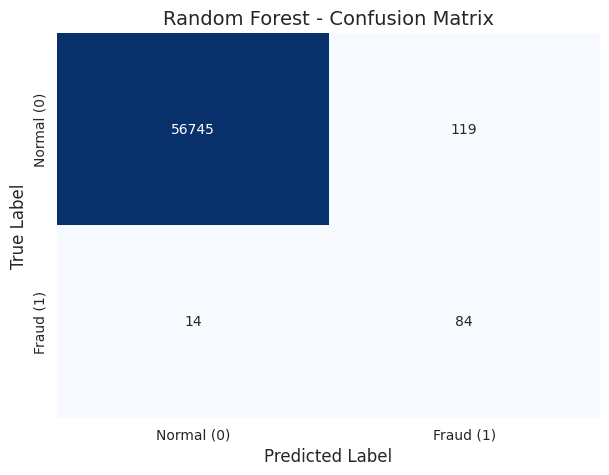

In [ ]:
# Import the Random Forest classifier and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Random Forest Classifier
# We set n_estimators=50 and max_depth=10 to keep the training time short
# while still achieving high performance. n_jobs=-1 uses all CPU cores.
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# 2. Train the model using the SMOTE-balanced training data
print("Training Random Forest model... (This might take about 1-2 minutes)")
rf_model.fit(X_train_smote, y_train_smote)

# 3. Make predictions on the UNSEEN test data
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate the model using robust metrics (Precision, Recall, F1-Score)
print("\n" + "="*40)
print("--- Random Forest Evaluation Report ---")
print("="*40)
print(classification_report(y_test, y_pred_rf))

# 5. Plot the Confusion Matrix for visual evaluation
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_rf)

# Use Seaborn heatmap to make it look professional for the IEEE report
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.title('Random Forest - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Isolation Forest

Training Isolation Forest model... (This is usually faster)

--- Isolation Forest Evaluation Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.30      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962



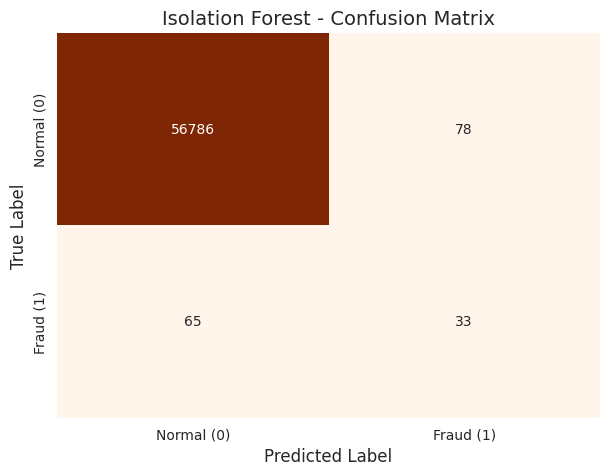

In [ ]:
# Import Isolation Forest from scikit-learn
from sklearn.ensemble import IsolationForest

# 1. Initialize the Isolation Forest Model
# Note: Isolation Forest is an unsupervised algorithm for anomaly detection.
# We set contamination to the expected ratio of outliers in our original dataset (~0.0017)
# For fair comparison, we will train it on the ORIGINAL (non-SMOTE) training data
iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42, n_jobs=-1)

# 2. Train the model using the ORIGINAL, UNBALANCED training data (X_train)
# Isolation Forest finds anomalies by isolating observations, it doesn't need balanced labels
print("Training Isolation Forest model... (This is usually faster)")
iso_forest.fit(X_train)

# 3. Make predictions on the test set
# Isolation Forest outputs -1 for outliers (fraud) and 1 for inliers (normal)
y_pred_iso_raw = iso_forest.predict(X_test)

# 4. Map the output to match our dataset's Class format (0 for normal, 1 for fraud)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso_raw]

# 5. Evaluate the Isolation Forest Model
print("\n" + "="*40)
print("--- Isolation Forest Evaluation Report ---")
print("="*40)
print(classification_report(y_test, y_pred_iso))

# 6. Plot the Confusion Matrix
plt.figure(figsize=(7, 5))
cm_iso = confusion_matrix(y_test, y_pred_iso)

sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.title('Isolation Forest - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Local Outlier Factor (LOF)

Training Local Outlier Factor model... (This might take a few minutes due to distance calculations)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(



--- Local Outlier Factor Evaluation Report ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     56864
           1       0.01      0.14      0.01        98

    accuracy                           0.95     56962
   macro avg       0.50      0.55      0.49     56962
weighted avg       1.00      0.95      0.97     56962



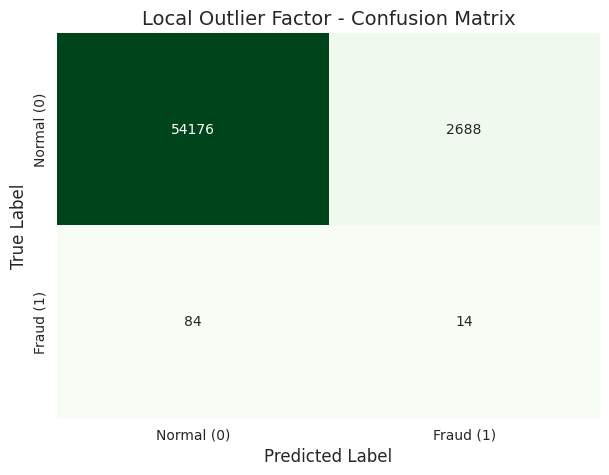

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Local Outlier Factor (LOF) Model
# novelty=True is required to predict on new, unseen data (X_test)
# n_jobs=-1 uses all processors because LOF calculates distances and can be computationally heavy
lof_model = LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1)

# 2. Train the model using the ORIGINAL, UNBALANCED training data (X_train)
print("Training Local Outlier Factor model... (This might take a few minutes due to distance calculations)")
lof_model.fit(X_train)

# 3. Make predictions on the test set
# LOF outputs -1 for outliers (fraud) and 1 for inliers (normal)
y_pred_lof_raw = lof_model.predict(X_test)

# 4. Map the output to match our dataset's Class format (0 for normal, 1 for fraud)
y_pred_lof = [1 if x == -1 else 0 for x in y_pred_lof_raw]

# 5. Evaluate the LOF Model
print("\n" + "="*40)
print("--- Local Outlier Factor Evaluation Report ---")
print("="*40)
print(classification_report(y_test, y_pred_lof))

# 6. Plot the Confusion Matrix
plt.figure(figsize=(7, 5))
cm_lof = confusion_matrix(y_test, y_pred_lof)

sns.heatmap(cm_lof, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.title('Local Outlier Factor - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

#graph

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


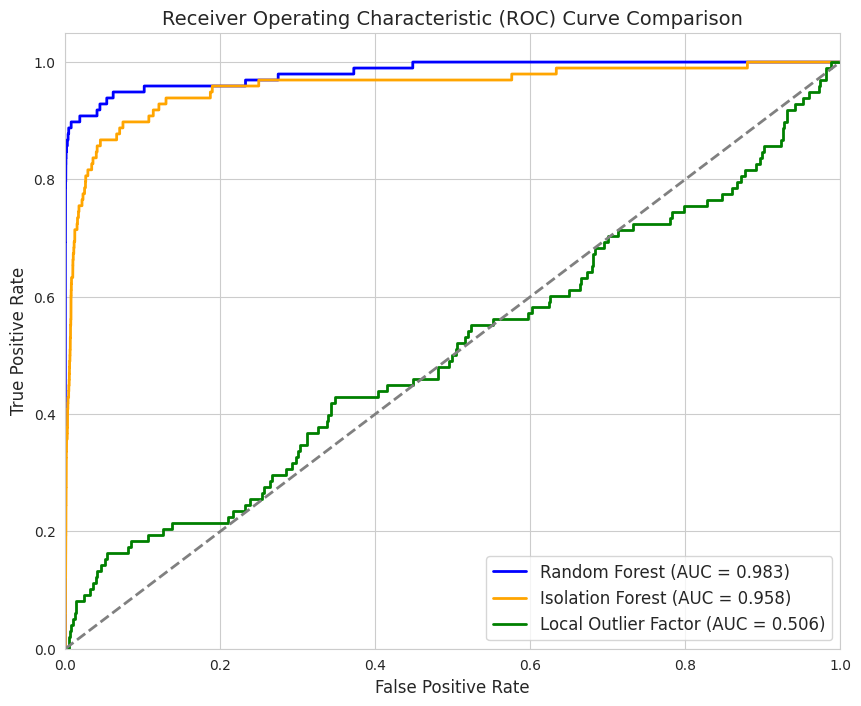

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Random Forest - Probability Score
# predict_proba returns the probability of the transaction being fraudulent (Class 1)
y_score_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 2. Isolation Forest - Anomaly Score
# decision_function assigns lower scores to anomalies.
# We invert this with a minus sign (-) to calculate the ROC curve correctly.
y_score_iso = -iso_forest.decision_function(X_test)
fpr_iso, tpr_iso, _ = roc_curve(y_test, y_score_iso)
roc_auc_iso = auc(fpr_iso, tpr_iso)

# 3. Local Outlier Factor - Anomaly Score
# Similarly, we invert the decision_function scores for LOF
y_score_lof = -lof_model.decision_function(X_test)
fpr_lof, tpr_lof, _ = roc_curve(y_test, y_score_lof)
roc_auc_lof = auc(fpr_lof, tpr_lof)

# --- Plotting the ROC Curve (Optimized for IEEE Report) ---
plt.figure(figsize=(10, 8))

# Plot the ROC curves for each model
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_iso, tpr_iso, color='orange', lw=2, label=f'Isolation Forest (AUC = {roc_auc_iso:.3f})')
plt.plot(fpr_lof, tpr_lof, color='green', lw=2, label=f'Local Outlier Factor (AUC = {roc_auc_lof:.3f})')

# Plot the random guess line (Reference baseline)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Chart formatting and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14)
plt.legend(loc="lower right", fontsize=12)

plt.show()